In [ ]:
# employee_salary_prediction.py

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Step 1: Load dataset (replace with your CSV file)
data = pd.read_csv("employee_salary_dataset.csv")
print("DataFrame columns:", data.columns.tolist())
# Example columns: ['YearsExperience', 'EducationLevel', 'Age', 'Salary']

# Step 2: Feature selection
X = data[['Experience_Years', 'Education_Level', 'Age']]
y = data['Monthly_Salary']

# Apply one-hot encoding to 'Education_Level' column
X = pd.get_dummies(X, columns=['Education_Level'], drop_first=True)

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5: Evaluate model
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Step 6: Save model
joblib.dump(model, "salary_prediction_model.pkl")

# Step 7: Load model and predict new salary
loaded_model = joblib.load("salary_prediction_model.pkl")

# For new prediction, ensure the new_employee DataFrame has the same one-hot encoded columns
new_employee_data = {'Experience_Years': [5], 'Education_Level': ['Master'], 'Age': [30]}
new_employee = pd.DataFrame(new_employee_data)
new_employee = pd.get_dummies(new_employee, columns=['Education_Level'], drop_first=True)

# Align columns - crucial for prediction if not all categories are present in new_employee
# Get all columns after one-hot encoding from the training data
training_columns = X.columns
# Reindex new_employee to match the training columns, filling missing with 0
new_employee = new_employee.reindex(columns=training_columns, fill_value=0)

predicted_salary = loaded_model.predict(new_employee)
print("Predicted Salary:", predicted_salary[0])

DataFrame columns: ['EmployeeID', 'Name', 'Department', 'Experience_Years', 'Education_Level', 'Age', 'Gender', 'City', 'Monthly_Salary']
Mean Squared Error: 1629010780.333224
R² Score: -0.38163878549193986
Predicted Salary: 93258.04982889512


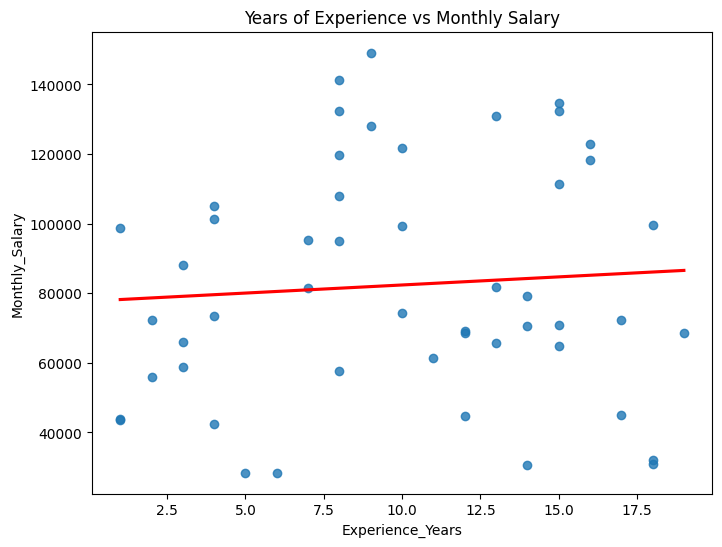

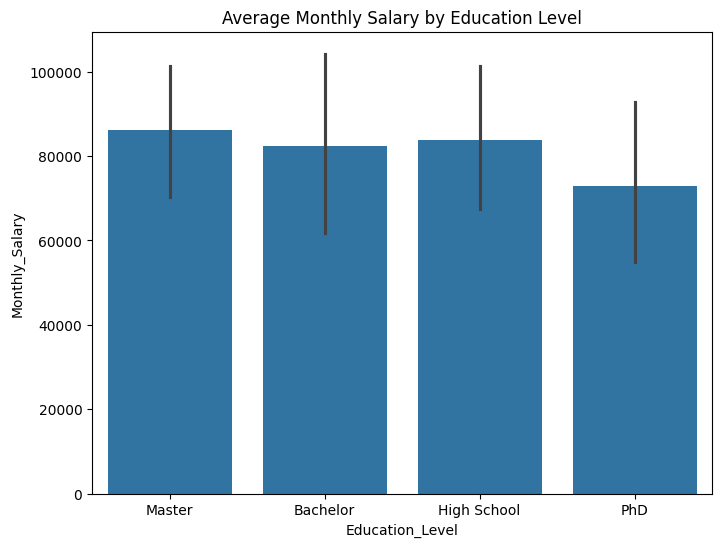

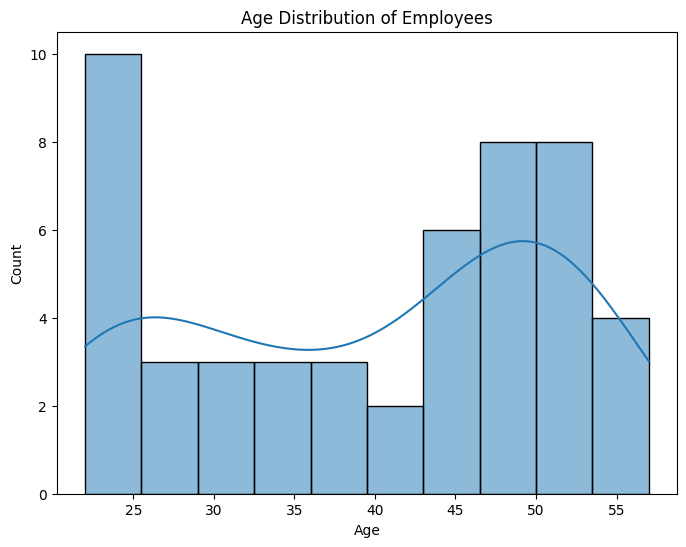

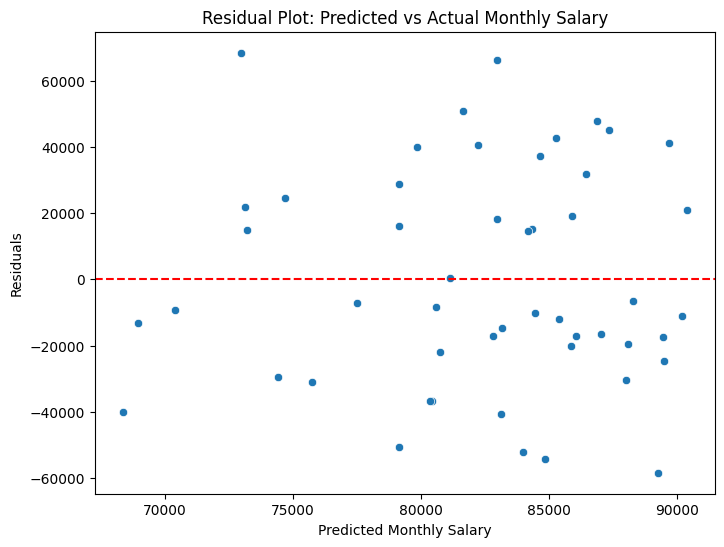

R2 Score: 0.02928946319704795
MSE: 1068959123.4026679
Predicted Salary: 93258.04982889512


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
data = pd.read_csv("employee_salary_dataset.csv")

# Scatter plot: YearsExperience vs Salary with regression line
plt.figure(figsize=(8,6))
sns.regplot(x="Experience_Years", y="Monthly_Salary", data=data, ci=None, line_kws={"color":"red"})
plt.title("Years of Experience vs Monthly Salary")
plt.show()

# Bar chart: Average salary by EducationLevel
plt.figure(figsize=(8,6))
sns.barplot(x="Education_Level", y="Monthly_Salary", data=data, estimator=lambda x: sum(x)/len(x))
plt.title("Average Monthly Salary by Education Level")
plt.show()

# Histogram: Age distribution
plt.figure(figsize=(8,6))
sns.histplot(data["Age"], bins=10, kde=True)
plt.title("Age Distribution of Employees")
plt.show()

# Residual plot: Predicted vs Actual Salary
# Apply one-hot encoding to 'Education_Level' column for the model
X = data[["Experience_Years","Education_Level","Age"]]
X = pd.get_dummies(X, columns=['Education_Level'], drop_first=True)
y = data["Monthly_Salary"]

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot: Predicted vs Actual Monthly Salary")
plt.xlabel("Predicted Monthly Salary")
plt.ylabel("Residuals")
plt.show()

print("R2 Score:", model.score(X, y))
print("MSE:", mean_squared_error(y, y_pred))
print("Predicted Salary:", predicted_salary[0])